# Model analysis: errors and feature importance

Both final models are evaluated on the **same stratified holdout** (80/20 split,
`random_state=42` — identical to the splits used in `04_log_reg_final.ipynb` and
`05_grad_boost.ipynb`):

- **log_reg** — SGDClassifier (hinge loss), merged configuration of grid-search
  candidates 227/263/299, one epoch over mini-batches of 128;
- **CatBoost** — baseline from `05_grad_boost.ipynb` (early stopping on the holdout).

Contents: balanced accuracy, per-class classification report, confusion matrices,
model coefficients (log_reg) and feature importances (CatBoost).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier

from data_preprocessing import DataProcessing

sns.set_style("darkgrid")
CLASS_NAMES = ["at-risk", "unhealthy", "fit"]

df = pd.read_csv("datasets/train.csv")
y = df["health_condition"]
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=y)
print(f"train: {train_df.shape}, val: {val_df.shape}")


train: (552070, 15), val: (138018, 15)


## 1. log_reg — evaluation

Preprocessing artifacts (median, OneHotEncoder, RobustScaler) are fitted on the
train part only and applied to the holdout — no data leakage.

In [2]:
# merged configuration of grid-search models 227/263/299
# (l1_ratio is ignored by SGDClassifier with penalty="l1")
LOG_REG_PARAMS = {
    "alpha": 0.0001, "eta0": 0.01, "learning_rate": "optimal",
    "loss": "hinge", "penalty": "l1", "power_t": 0.5,
    "random_state": 42, "shuffle": True,
}
BATCH_SIZE = 128

train_prep = DataProcessing(train_df, data_type="train")
val_prep = DataProcessing(val_df, data_type="train")

train_prep_df = train_prep.df_prepr()
X_train = train_prep_df.drop(columns=["health_condition"])
y_train = train_prep_df["health_condition"]

val_prep.median = train_prep.median
val_prep.encoder = train_prep.encoder
val_prep.scaler = train_prep.scaler
val_prep_df = val_prep.df_prepr()
X_val = val_prep_df.drop(columns=["health_condition"])
y_val = val_prep_df["health_condition"]

class_weight = dict(zip(np.unique(y_train),
                        y_train.shape[0] / (len(np.unique(y_train)) * np.bincount(y_train))))
model_lr = SGDClassifier(**LOG_REG_PARAMS, class_weight=class_weight)

n_batches = int(np.ceil(len(X_train) / BATCH_SIZE))
for i in range(n_batches):
    start = i * BATCH_SIZE
    end = min((i + 1) * BATCH_SIZE, len(X_train))
    model_lr.partial_fit(X_train.iloc[start:end], y_train.iloc[start:end],
                         classes=np.unique(y_train))

y_pred_lr = model_lr.predict(X_val)
print(f"log_reg balanced accuracy (holdout): {balanced_accuracy_score(y_val, y_pred_lr):.4f}\n")
print(classification_report(y_val, y_pred_lr, target_names=CLASS_NAMES))


Столбец sleep_duration: 0
Столбец heart_rate: 0
Столбец bmi: 0
Столбец calorie_expenditure: 0
Столбец step_count: 0
Столбец exercise_duration: 0
Столбец water_intake: 0
Столбец diet_type: 0
Столбец stress_level: 0


Столбец sleep_quality: 0
Столбец physical_activity_level: 0
Столбец smoking_alcohol: 0
Столбец gender: 0


Столбец sleep_duration: 0
Столбец heart_rate: 0
Столбец bmi: 0
Столбец calorie_expenditure: 0
Столбец step_count: 0
Столбец exercise_duration: 0
Столбец water_intake: 0
Столбец diet_type: 0
Столбец stress_level: 0
Столбец sleep_quality: 0
Столбец physical_activity_level: 0
Столбец smoking_alcohol: 0


Столбец gender: 0


log_reg balanced accuracy (holdout): 0.8859

              precision    recall  f1-score   support

     at-risk       0.98      0.89      0.93    115871
   unhealthy       0.59      0.86      0.70     11320
         fit       0.54      0.90      0.68      7806

    accuracy                           0.89    134997
   macro avg       0.71      0.89      0.77    134997
weighted avg       0.92      0.89      0.90    134997



### Model coefficients

For a linear model the (absolute) coefficients are a direct measure of feature
influence, averaged here over the three one-vs-rest class heads.

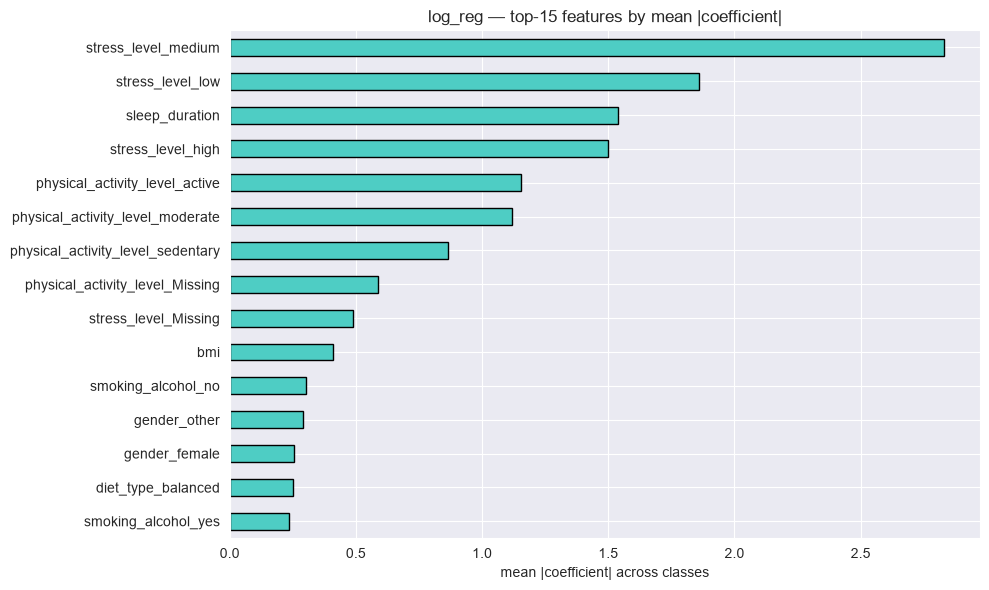

In [3]:
coef = np.abs(model_lr.coef_).mean(axis=0)
coef_s = pd.Series(coef, index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
coef_s.sort_values().plot.barh(ax=ax, color="#4ECDC4", edgecolor="black")
ax.set_title("log_reg — top-15 features by mean |coefficient|")
ax.set_xlabel("mean |coefficient| across classes")
plt.tight_layout()
plt.savefig("log_reg_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()


## 2. CatBoost — evaluation

Baseline configuration (tuning in `06_grad_boost_tuning.ipynb` gave no meaningful
gain, so the simpler model is kept).

In [4]:
CATEGORICAL_FEATURES = ["diet_type", "stress_level", "sleep_quality",
                        "physical_activity_level", "smoking_alcohol", "gender"]

cb_train = train_df[~(train_df.isnull().sum(axis=1) >= 3)].copy()
cb_val = val_df[~(val_df.isnull().sum(axis=1) >= 3)].copy()
for part in (cb_train, cb_val):
    part[CATEGORICAL_FEATURES] = part[CATEGORICAL_FEATURES].fillna("Unknown").astype(str)

le = LabelEncoder()
y_train_cb = le.fit_transform(cb_train["health_condition"])
y_val_cb = le.transform(cb_val["health_condition"])

X_train_cb = cb_train.drop(columns=["health_condition", "id"])
X_val_cb = cb_val.drop(columns=["health_condition", "id"])

model_cb = CatBoostClassifier(
    iterations=1000, loss_function="MultiClass", eval_metric="MultiClass",
    early_stopping_rounds=50, random_seed=42, train_dir="catboost_info", verbose=100,
)
model_cb.fit(X_train_cb, y_train_cb, cat_features=CATEGORICAL_FEATURES,
             eval_set=(X_val_cb, y_val_cb), verbose=100)

y_pred_cb = model_cb.predict(X_val_cb).astype(int).ravel()
print(f"CatBoost balanced accuracy (holdout): {balanced_accuracy_score(y_val_cb, y_pred_cb):.4f}\n")
print(classification_report(y_val_cb, y_pred_cb, target_names=le.classes_))


Learning rate set to 0.122455


0:	learn: 0.9078477	test: 0.9075473	best: 0.9075473 (0)	total: 1.59s	remaining: 26m 29s


100:	learn: 0.0887025	test: 0.0887142	best: 0.0887142 (100)	total: 2m 11s	remaining: 19m 34s


200:	learn: 0.0865986	test: 0.0874425	best: 0.0874425 (200)	total: 4m 20s	remaining: 17m 16s


300:	learn: 0.0854283	test: 0.0869543	best: 0.0869543 (300)	total: 6m 25s	remaining: 14m 54s


...

600:	learn: 0.0824894	test: 0.0863960	best: 0.0863898 (596)	total: 12m 28s	remaining: 8m 16s


700:	learn: 0.0816698	test: 0.0863683	best: 0.0863631 (685)	total: 14m 24s	remaining: 6m 8s


800:	learn: 0.0808407	test: 0.0862790	best: 0.0862677 (778)	total: 16m 22s	remaining: 4m 4s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.08626772631
bestIteration = 778

Shrink model to first 779 iterations.


CatBoost balanced accuracy (holdout): 0.8816

              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    115871
         fit       0.94      0.83      0.88      7806
   unhealthy       0.95      0.82      0.88     11320

    accuracy                           0.97    134997
   macro avg       0.95      0.88      0.91    134997
weighted avg       0.97      0.97      0.97    134997



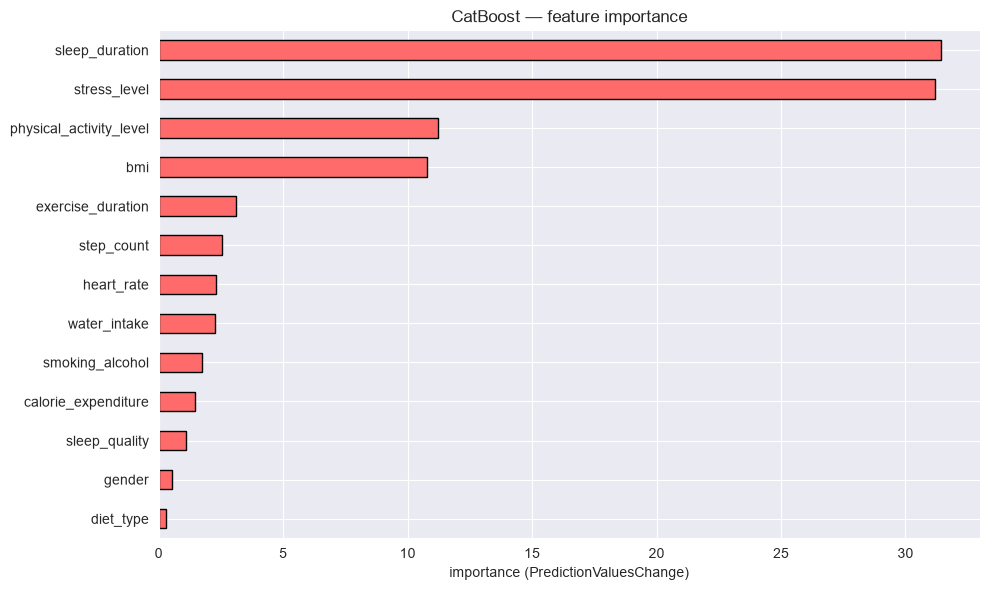

In [5]:
importances = pd.Series(model_cb.get_feature_importance(),
                        index=X_train_cb.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot.barh(ax=ax, color="#FF6B6B", edgecolor="black")
ax.set_title("CatBoost — feature importance")
ax.set_xlabel("importance (PredictionValuesChange)")
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Confusion matrices (common holdout)

Both models share the same error structure — errors concentrate on the boundary
between `at-risk` and the two minority classes, but the direction differs with
the training setup:

- **log_reg** (balanced `class_weight` pushes towards the minorities)
  over-predicts them: `at-risk` → `unhealthy` 6,587 and `at-risk` → `fit` 5,878;
- **CatBoost** absorbs errors into the majority class: `unhealthy` → `at-risk`
  2,044 and `fit` → `at-risk` 1,263.

In both cases `unhealthy` is the least-recalled class (0.86 / 0.82) —
the two "unhealthy-ish" states genuinely overlap in feature space.

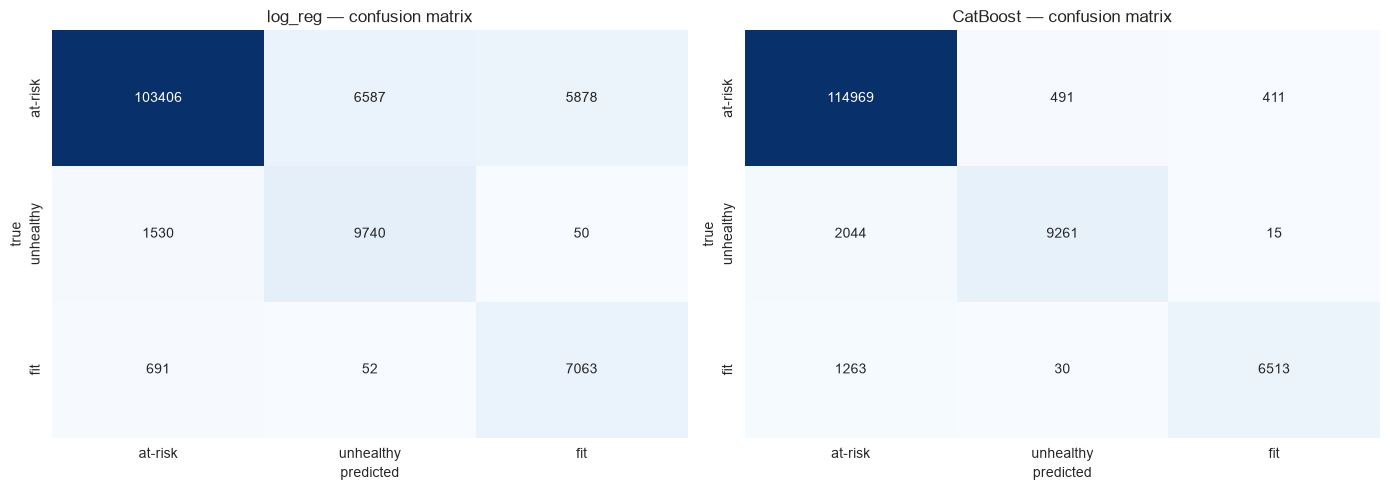

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, labels, title in [
    (axes[0], y_val.values, y_pred_lr, [0, 1, 2], "log_reg"),
    (axes[1], le.inverse_transform(y_val_cb), le.inverse_transform(y_pred_cb), CLASS_NAMES, "CatBoost"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{title} — confusion matrix")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusions

1. Both models reach ~0.88–0.89 balanced accuracy on the holdout, consistent
   with the Kaggle leaderboard scores (0.88298 / 0.87466) — validation is honest.
2. The dominant error source is the `unhealthy` ↔ `at-risk` boundary for both
   model families (recall of `unhealthy`: 0.86 / 0.82) — a data-intrinsic
   overlap rather than a model deficiency. Balanced class weights in log_reg
   trade majority-class precision for minority recall; CatBoost does the opposite.
3. Feature rankings agree between the statistical tests
   (`02_statistical_tests.ipynb`), the linear model coefficients and CatBoost
   importances: lifestyle features (stress, activity, sleep) carry the signal.
4. The linear model performs on par with gradient boosting → the class
   structure is close to linearly separable, so the simpler and interpretable
   model is preferable here.